In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import warnings
from scipy.stats import ttest_rel

In [3]:
# Per case metrics (raw):
TEST_METRICS_CSVS = {
    "micro_ACE": "micro_ace_raw.csv",
    "macro_ACE": "macro_ace_raw.csv",
    "micro_ECE": "micro_ece_raw.csv",
    "macro_ECE": "macro_ece_raw.csv",
    "micro_MCE": "micro_mce_raw.csv",
    "macro_MCE": "macro_mce_raw.csv",
    "DSC": "mean_dice_raw.csv",
}

# Metrics summary:
TEST_METRICS_CSVS_SUMMARY = {
    "micro_ACE": "micro_ace_summary.csv",
    "macro_ACE": "macro_ace_summary.csv",
    "micro_ECE": "micro_ece_summary.csv",
    "macro_ECE": "macro_ece_summary.csv",
    "micro_MCE": "micro_mce_summary.csv",
    "macro_MCE": "macro_mce_summary.csv",
    "DSC": "mean_dice_summary.csv",
}

SEED = 12345

In [4]:
# Updated ACDC runs with new experiments
RUNS_ACDC = {
    "acdc": {
        "baseline": "../bundles/acdc17_baseline_dice_ce_2",
        "hardl1ace": "../bundles/acdc17_hardl1ace_dice_ce_2",
        "softl1ace": "../bundles/acdc17_softl1ace_dice_ce_2",
    }
}

In [18]:
def load_csv_files(run, no_HEC=False):
    """Load CSV files for a given run."""
    dataframes = {}
    
    # Load raw CSV files
    for metric, csv_file in TEST_METRICS_CSVS.items():
        if no_HEC:
            csv_path = os.path.join(run, f'seed_{SEED}', "inference_results_no_HEC", csv_file)
        else:
            csv_path = os.path.join(run, f'seed_{SEED}', "inference_results", csv_file)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            if metric not in dataframes:
                dataframes[metric] = {}
            dataframes[metric]["raw"] = df
        else:
            warnings.warn(f"File does not exist: {csv_path}")
    
    # Load summary CSV files
    for metric, csv_file in TEST_METRICS_CSVS_SUMMARY.items():
        if no_HEC:
            csv_path = os.path.join(run, f'seed_{SEED}', "inference_results_no_HEC", csv_file)
        else:
            csv_path = os.path.join(run, f'seed_{SEED}', "inference_results", csv_file)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            if metric not in dataframes:
                dataframes[metric] = {}
            dataframes[metric]["summary"] = df
        else:
            warnings.warn(f"File does not exist: {csv_path}")
    
    return dataframes


def load_results(runs, no_HEC=False):
    """Load all results for specified runs."""
    results = {}
    for key in runs:
        results[key] = {}
        for run_key, run in runs[key].items():
            results[key][run_key] = load_csv_files(run, no_HEC)
            print(f"Loaded {key} {run_key}")
    return results

In [6]:
def create_acdc_table(results, avg_type="micro"):
    """Create a table showing DSC and ACE metrics for ACDC dataset."""
    def get_metrics(dataframes, dataset_key, run_key, metric):
        try:
            df = dataframes[dataset_key][run_key][metric]["summary"]
            mean = df[df["class"] == "mean"]["mean"].values[0]
            std = df[df["class"] == "mean"]["std"].values[0]
            return mean, std
        except KeyError:
            return None, None

    table_data = []
    for loss_function, run_key in zip(
        ["Baseline", "Hard L1-ACE", "Soft L1-ACE"],
        ["baseline", "hardl1ace", "softl1ace"],
    ):
        row = [loss_function]
        
        # DSC
        dsc_mean, dsc_std = get_metrics(results, "acdc", run_key, "DSC")
        if dsc_mean is not None:
            row.append(f"{dsc_mean:.3f} ± {dsc_std:.3f}")
        else:
            row.append("N/A")
        
        # ACE
        ace_mean, ace_std = get_metrics(results, "acdc", run_key, f"{avg_type}_ACE")
        if ace_mean is not None:
            row.append(f"{ace_mean:.3f} ± {ace_std:.3f}")
        else:
            row.append("N/A")
        
        # ECE
        ece_mean, ece_std = get_metrics(results, "acdc", run_key, f"{avg_type}_ECE")
        if ece_mean is not None:
            row.append(f"{ece_mean:.3f} ± {ece_std:.3f}")
        else:
            row.append("N/A")
        
        # MCE
        mce_mean, mce_std = get_metrics(results, "acdc", run_key, f"{avg_type}_MCE")
        if mce_mean is not None:
            row.append(f"{mce_mean:.3f} ± {mce_std:.3f}")
        else:
            row.append("N/A")
        
        table_data.append(row)

    headers = [
        "Loss Function",
        "ACDC 17 DSC",
        f"ACDC 17 {avg_type.upper()} ACE",
        f"ACDC 17 {avg_type.upper()} ECE",
        f"ACDC 17 {avg_type.upper()} MCE",
    ]
    
    print(f"\n=== ACDC Results ({avg_type.upper()}) ===")
    print(tabulate(table_data, headers=headers, tablefmt="pipe"))

In [7]:
def create_spider_plot(results, avg_type="micro", save_fig=True):
    """Create spider/radar plot for ACDC dataset."""
    metrics = ["ACE", "ECE", "MCE", "DSC"]
    dataset = "acdc"
    loss_functions = ["baseline", "hardl1ace", "softl1ace"]
    output_dir = "../results_plots/radar_plots_acdc_new"
    os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    # Get baseline values for normalization
    baseline_values = []
    for metric in metrics:
        metric_key = f"{avg_type}_{metric}" if metric != "DSC" else metric
        try:
            df = results[dataset]["baseline"][metric_key]["summary"]
            mean = df[df["class"] == "mean"]["mean"].values[0]
            baseline_values.append(mean)
        except KeyError:
            baseline_values.append(1)

    # Plot each loss function
    for loss_function in loss_functions:
        values = []
        for metric, baseline in zip(metrics, baseline_values):
            metric_key = f"{avg_type}_{metric}" if metric != "DSC" else metric
            try:
                df = results[dataset][loss_function][metric_key]["summary"]
                mean = df[df["class"] == "mean"]["mean"].values[0]
                normalized_value = mean / baseline if baseline != 0 else 0
                values.append(normalized_value)
            except KeyError:
                values.append(0)
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle="solid", label=loss_function)
        ax.fill(angles, values, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], metrics, fontsize=20)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], color="black", size=20)
    plt.ylim(0, 1.1)

    print(f"Normalized Spider Plot for ACDC Dataset ({avg_type.upper()})")

    if save_fig:
        pdf_filename = os.path.join(output_dir, f"normalized_spider_plot_acdc_{avg_type}.pdf")
        plt.savefig(pdf_filename, format="pdf")
        print(f"Saved to: {pdf_filename}")
    plt.show()

In [15]:
def calculate_p_values(results):
    """Calculate p-values comparing baseline to Hard L1-ACE and Soft L1-ACE."""
    # Metrics to test (only macro metrics and DSC)
    metrics_to_test = ["DSC", "macro_ACE", "macro_ECE", "macro_MCE"]
    
    print("\n=== Statistical Significance Tests (Paired t-test) ===\n")
    
    results_table = []
    
    for metric in metrics_to_test:
        try:
            # Load raw data (per-case values)
            # Check if 'raw' key exists in the nested structure
            if metric not in results["acdc"]["baseline"]:
                print(f"Metric {metric} not found in results")
                results_table.append([metric, "N/A", "N/A"])
                continue
                
            if "raw" not in results["acdc"]["baseline"][metric]:
                print(f"Raw data not found for {metric}")
                results_table.append([metric, "N/A", "N/A"])
                continue
            
            df_base = results["acdc"]["baseline"][metric]["raw"]
            df_hard = results["acdc"]["hardl1ace"][metric]["raw"]
            df_soft = results["acdc"]["softl1ace"][metric]["raw"]
            
            # Extract mean column values
            base_vals = df_base["mean"].values
            hard_vals = df_hard["mean"].values
            soft_vals = df_soft["mean"].values
            
            # Perform paired t-tests
            try:
                _, p_val_hard = ttest_rel(base_vals, hard_vals)
            except Exception as e:
                print(f"Error in t-test for {metric} (hard): {e}")
                p_val_hard = np.nan
            
            try:
                _, p_val_soft = ttest_rel(base_vals, soft_vals)
            except Exception as e:
                print(f"Error in t-test for {metric} (soft): {e}")
                p_val_soft = np.nan
            
            # Format p-values
            p_hard_str = f"{p_val_hard:.3e}" if not np.isnan(p_val_hard) else "N/A"
            p_soft_str = f"{p_val_soft:.3e}" if not np.isnan(p_val_soft) else "N/A"
            
            # Add significance markers
            if not np.isnan(p_val_hard):
                if p_val_hard < 0.001:
                    p_hard_str += " ***"
                elif p_val_hard < 0.01:
                    p_hard_str += " **"
                elif p_val_hard < 0.05:
                    p_hard_str += " *"
            
            if not np.isnan(p_val_soft):
                if p_val_soft < 0.001:
                    p_soft_str += " ***"
                elif p_val_soft < 0.01:
                    p_soft_str += " **"
                elif p_val_soft < 0.05:
                    p_soft_str += " *"
            
            results_table.append([metric, p_hard_str, p_soft_str])
            
        except Exception as e:
            print(f"Error processing {metric}: {e}")
            import traceback
            traceback.print_exc()
            results_table.append([metric, "Error", "Error"])
    
    headers = [
        "Metric",
        "Baseline vs Hard L1-ACE",
        "Baseline vs Soft L1-ACE",
    ]
    print(tabulate(results_table, headers=headers, tablefmt="pipe"))
    print("\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001")

## Load ACDC Data

In [19]:
results = load_results(RUNS_ACDC)

Loaded acdc baseline
Loaded acdc hardl1ace
Loaded acdc softl1ace


## Macro Results (Per-case averaged)

In [10]:
create_acdc_table(results, avg_type="macro")


=== ACDC Results (MACRO) ===
| Loss Function   | ACDC 17 DSC   | ACDC 17 MACRO ACE   | ACDC 17 MACRO ECE   | ACDC 17 MACRO MCE   |
|:----------------|:--------------|:--------------------|:--------------------|:--------------------|
| Baseline        | 0.871 ± 0.037 | 0.136 ± 0.029       | 0.002 ± 0.001       | 0.297 ± 0.066       |
| Hard L1-ACE     | 0.870 ± 0.039 | 0.101 ± 0.029       | 0.001 ± 0.001       | 0.213 ± 0.058       |
| Soft L1-ACE     | 0.864 ± 0.044 | 0.073 ± 0.030       | 0.001 ± 0.001       | 0.151 ± 0.054       |


Normalized Spider Plot for ACDC Dataset (MACRO)
Saved to: ../results_plots/radar_plots_acdc_new/normalized_spider_plot_acdc_macro.pdf


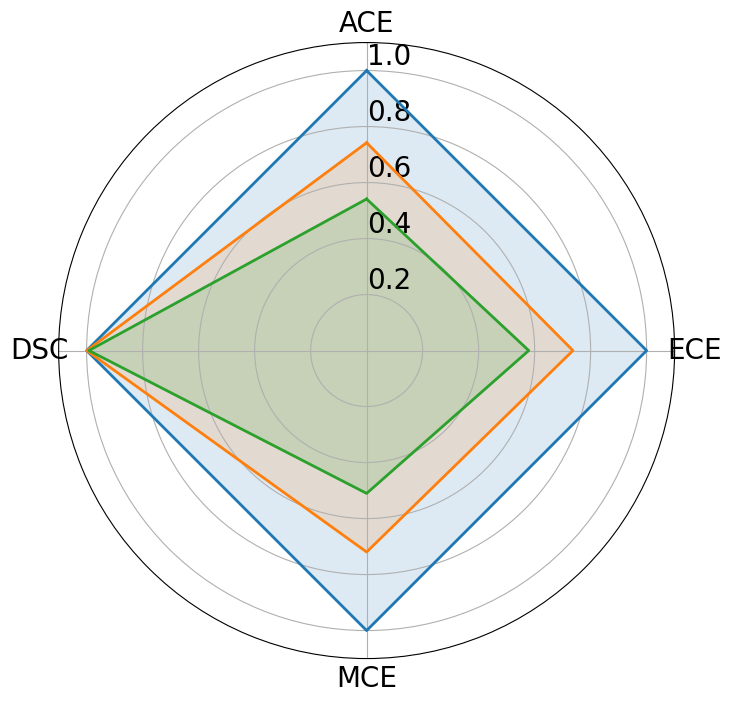

In [11]:
create_spider_plot(results, avg_type="macro", save_fig=True)

## Micro Results (Aggregated binning)

In [12]:
create_acdc_table(results, avg_type="micro")


=== ACDC Results (MICRO) ===
| Loss Function   | ACDC 17 DSC   | ACDC 17 MICRO ACE   | ACDC 17 MICRO ECE   | ACDC 17 MICRO MCE   |
|:----------------|:--------------|:--------------------|:--------------------|:--------------------|
| Baseline        | 0.871 ± 0.037 | 0.116 ± 0.000       | 0.002 ± 0.000       | 0.223 ± 0.000       |
| Hard L1-ACE     | 0.870 ± 0.039 | 0.069 ± 0.000       | 0.001 ± 0.000       | 0.125 ± 0.000       |
| Soft L1-ACE     | 0.864 ± 0.044 | 0.035 ± 0.000       | 0.001 ± 0.000       | 0.065 ± 0.000       |


Normalized Spider Plot for ACDC Dataset (MICRO)
Saved to: ../results_plots/radar_plots_acdc_new/normalized_spider_plot_acdc_micro.pdf
Saved to: ../results_plots/radar_plots_acdc_new/normalized_spider_plot_acdc_micro.pdf


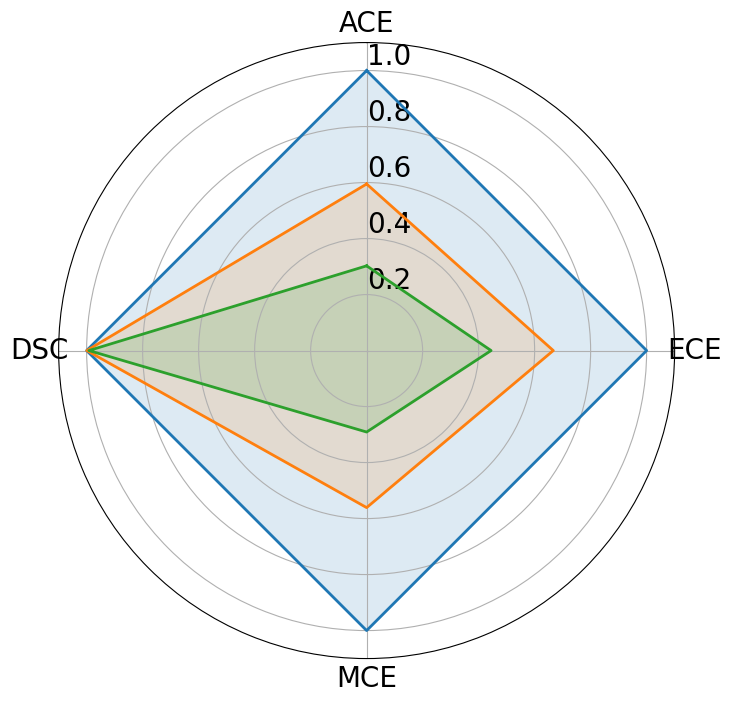

In [13]:
create_spider_plot(results, avg_type="micro", save_fig=True)

## Statistical Significance Tests

In [21]:
calculate_p_values(results)


=== Statistical Significance Tests (Paired t-test) ===

| Metric    | Baseline vs Hard L1-ACE   | Baseline vs Soft L1-ACE   |
|:----------|:--------------------------|:--------------------------|
| DSC       | 8.042e-01                 | 1.170e-03 **              |
| macro_ACE | 4.162e-26 ***             | 1.930e-45 ***             |
| macro_ECE | 2.324e-20 ***             | 4.034e-23 ***             |
| macro_MCE | 2.692e-30 ***             | 5.829e-49 ***             |

Significance levels: * p<0.05, ** p<0.01, *** p<0.001
